# Strategy 4: Curve Trades — Hawk Flattener / Dove Steepener

Instead of betting on outright rate direction, trade the **curve spread**:
- **Hawks** → flattener: pay front (IMM\_1×IMM\_2) + receive back (IMM\_3×IMM\_4)
- **Doves** → steepener: receive front + pay back

Rationale: Hawks push front-end rates up more than the belly. Curve trades hedge out
parallel rate moves from oil/macro noise that dominated 2026 outright performance.

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, r"C:\Users\chris\clee\ARBS")
import datetime, pytz, re, numpy as np, pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt, matplotlib.pylab as pylab, seaborn as sns
plt.style.use("ggplot")
pylab.rcParams.update({"legend.fontsize": "large", "figure.figsize": (14, 8),
    "axes.labelsize": "x-large", "axes.titlesize": "x-large",
    "xtick.labelsize": "large", "ytick.labelsize": "large"})
import QuantLib as ql

NYC_tz = pytz.timezone("America/New_York")
ENTRY_OFFSET = datetime.timedelta(minutes=45)
EXIT_OFFSET  = datetime.timedelta(minutes=180)
CURVE = "USD-SOFR-1D-Q12STIRT"
FRONT_TENOR = "IMM_1xIMM_2"
BACK_TENOR  = "IMM_3xIMM_4"
BASE_BPV = 100_000
MDP_SOURCE = "BARCHART_STIRF-RL"
BT_START = "2021-01-01"
BT_END   = "2026-06-30"
HAWK_THRESH = 10
DOVE_THRESH = -10
EARLIEST_SPEECH = datetime.time(7, 0)
LATEST_SPEECH   = datetime.time(17, 0)
BLACKOUT_BD = 1
SCORE_METRIC = "trailing_5_avg"

print("Config loaded.")
print(f"Front leg: {FRONT_TENOR}, Back leg: {BACK_TENOR}")

Config loaded.
Front leg: IMM_1xIMM_2, Back leg: IMM_3xIMM_4


## 1. Load Data

In [2]:
from RVUtils.forex_factory_calendar import ForexFactoryCalendarFetcher, ForexFactoryTheme
fetcher = ForexFactoryCalendarFetcher()
fed_speak_df = fetcher.fetch_range(BT_START, BT_END,
    themes=[ForexFactoryTheme.FED_SPEAKERS], show_tqdm=True, bulk_chunk_weeks=52)
print(f"ForexFactory events: {len(fed_speak_df)}")

jpm = pd.read_csv(r"C:\Users\chris\clee\project-oasis\private\jpm_research\fed_speak_nlp\fed_hawk_dove_scores.csv")
jpm["date"] = pd.to_datetime(jpm["date"]).dt.date
jpm = jpm.sort_values(["speaker", "date"]).reset_index(drop=True)
KNOWN_SPEAKERS = sorted(jpm["speaker"].unique())

_cache = {}
for speaker, grp in jpm.groupby("speaker"):
    g = grp.sort_values("date")
    _cache[speaker] = (g["date"].values, g[SCORE_METRIC].values)

def get_score(speaker, as_of):
    if speaker not in _cache: return np.nan
    dates, scores = _cache[speaker]
    mask = dates < np.datetime64(as_of)
    return float(scores[mask][-1]) if mask.any() else np.nan

print(f"JPM speakers: {len(KNOWN_SPEAKERS)}")

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]

ForexFactory events: 1483
JPM speakers: 23


## 2. Build Trade Events

In [3]:
FOMC_DATES = [
    datetime.date(2020,1,29),datetime.date(2020,3,15),datetime.date(2020,4,29),
    datetime.date(2020,6,10),datetime.date(2020,7,29),datetime.date(2020,9,16),
    datetime.date(2020,11,5),datetime.date(2020,12,16),
    datetime.date(2021,1,27),datetime.date(2021,3,17),datetime.date(2021,4,28),
    datetime.date(2021,6,16),datetime.date(2021,7,28),datetime.date(2021,9,22),
    datetime.date(2021,11,3),datetime.date(2021,12,15),
    datetime.date(2022,1,26),datetime.date(2022,3,16),datetime.date(2022,5,4),
    datetime.date(2022,6,15),datetime.date(2022,7,27),datetime.date(2022,9,21),
    datetime.date(2022,11,2),datetime.date(2022,12,14),
    datetime.date(2023,2,1),datetime.date(2023,3,22),datetime.date(2023,5,3),
    datetime.date(2023,6,14),datetime.date(2023,7,26),datetime.date(2023,9,20),
    datetime.date(2023,11,1),datetime.date(2023,12,13),
    datetime.date(2024,1,31),datetime.date(2024,3,20),datetime.date(2024,5,1),
    datetime.date(2024,6,12),datetime.date(2024,7,31),datetime.date(2024,9,18),
    datetime.date(2024,11,7),datetime.date(2024,12,18),
    datetime.date(2025,1,29),datetime.date(2025,3,19),datetime.date(2025,5,7),
    datetime.date(2025,6,18),datetime.date(2025,7,30),datetime.date(2025,9,17),
    datetime.date(2025,10,29),datetime.date(2025,12,10),
    datetime.date(2026,1,28),datetime.date(2026,3,18),datetime.date(2026,4,29),
    datetime.date(2026,6,17),
]
ql_cal = ql.UnitedStates(ql.UnitedStates.GovernmentBond)

def extract_speaker(title):
    cleaned = re.sub(r"\b(Speaks?|Testifies|Testimony)\b", "", title).strip()
    return cleaned.split()[-1] if cleaned.split() else ""

def is_in_blackout(event_date):
    for f in FOMC_DATES:
        s = ql.Date(f.day, f.month, f.year)
        lo = ql_cal.advance(s, ql.Period(-BLACKOUT_BD, ql.Days), ql.Preceding)
        hi = ql_cal.advance(s, ql.Period(BLACKOUT_BD, ql.Days), ql.Following)
        if (datetime.date(lo.year(), lo.month(), lo.dayOfMonth())
                <= event_date <= datetime.date(hi.year(), hi.month(), hi.dayOfMonth())):
            return True
    return False

def cap_exit(exit_ts, entry_ts):
    eq = ql.Date(exit_ts.day, exit_ts.month, exit_ts.year)
    if exit_ts.hour >= 17:
        return exit_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    if not ql_cal.isBusinessDay(eq):
        return entry_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    return exit_ts

trade_events = []
excluded = defaultdict(int)
for _, row in fed_speak_df.iterrows():
    speaker = extract_speaker(row["Title"])
    if speaker not in KNOWN_SPEAKERS:
        excluded["unknown"] += 1; continue
    ts = row["TimestampNYC"]
    if pd.isna(ts):
        excluded["no_ts"] += 1; continue
    if ts.tzinfo is None:
        ts = NYC_tz.localize(ts)
    if ts.time() < EARLIEST_SPEECH or ts.time() > LATEST_SPEECH:
        excluded["hours"] += 1; continue
    if is_in_blackout(ts.date()):
        excluded["blackout"] += 1; continue
    if "press conference" in row["Title"].lower():
        excluded["presser"] += 1; continue
    score = get_score(speaker, ts.date())
    if pd.isna(score):
        excluded["no_score"] += 1; continue
    if score >= HAWK_THRESH:
        d = 1
    elif score <= DOVE_THRESH:
        d = -1
    else:
        excluded["neutral"] += 1; continue
    entry = ts - ENTRY_OFFSET
    eq = ql.Date(entry.day, entry.month, entry.year)
    if not ql_cal.isBusinessDay(eq):
        excluded["entry_bday"] += 1; continue
    exit_ = cap_exit(ts + EXIT_OFFSET, entry)
    trade_events.append({
        "speaker": speaker, "speech_ts": ts,
        "entry_ts": entry, "exit_ts": exit_,
        "direction": d, "score": score,
        "tag": f"ev_{len(trade_events)}",
    })

trade_events.sort(key=lambda e: e["entry_ts"])
filt, last = [], None
for ev in trade_events:
    if last is not None and ev["entry_ts"] < last: continue
    filt.append(ev)
    last = ev["exit_ts"]
trade_events = filt

n_h = sum(1 for e in trade_events if e["direction"] == 1)
n_d = sum(1 for e in trade_events if e["direction"] == -1)
print(f"Filtering: {dict(excluded)}")
print(f"Final trades: {len(trade_events)} (hawk={n_h}, dove={n_d})")

Filtering: {'unknown': 115, 'no_score': 220, 'blackout': 8, 'hours': 171, 'neutral': 329, 'entry_bday': 19}
Final trades: 461 (hawk=386, dove=75)


## 3. Run Backtests — Front Leg, Back Leg, and Outright

In [4]:
from BT.data_handler import TimeGrid
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import Trigger, FlowSignalTriggerRequirements
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

curve_mdp = IRSwapsMDP(source=MDP_SOURCE)

def run_leg(events, tenor, bpv_sign_fn, label):
    # bpv_sign_fn(direction) returns the bpv sign for this leg
    exit_set = set(e["exit_ts"] for e in events)
    ts_all = sorted(set(e["entry_ts"] for e in events) | exit_set)
    exit_trig = Trigger(
        trigger_requirements=FlowSignalTriggerRequirements(
            signal_fn=lambda s, bt: s in exit_set),
        actions=[UnwindPositionsAction(match_all=True, fee=0.0)])
    entry_trigs = []
    for ev in events:
        _ts = ev["entry_ts"]
        bpv = bpv_sign_fn(ev["direction"]) * BASE_BPV
        _q = IRSwapQuery(curve=CURVE, tenor=tenor, value=IRSwapValue.NPV,
            structure_kwargs={"bpv": bpv}, tags=(ev["tag"],),
            meta={"speaker": ev["speaker"], "direction": ev["direction"], "score": ev["score"]})
        def _mk(t):
            def fn(s, bt): return s == t and len(bt.portfolio.positions) == 0
            return fn
        entry_trigs.append(Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_mk(_ts)),
            actions=[AddQueryAction(query=_q)]))
    strat = QueryStrategy(name=label, triggers=[exit_trig] + entry_trigs)
    bt = QueryDrivenBacktest(time_grid=TimeGrid(ts_all), mdp=curve_mdp, strategy=strat,
                             show_progress=True, progress_desc=f"  {label}")
    bt.run()
    cl = pd.DataFrame(bt.portfolio.closed_positions_log)
    cl["tag"] = cl["source_query"].apply(lambda q: list(q.tags)[0])
    cl["speaker"] = cl["source_query"].apply(lambda q: q.meta["speaker"])
    cl["direction"] = cl["source_query"].apply(lambda q: q.meta["direction"])
    cl["score"] = cl["source_query"].apply(lambda q: q.meta["score"])
    cl["opened_at"] = pd.to_datetime(cl["opened_at"])
    cl["year"] = cl["opened_at"].dt.year
    cl["pnl_bps"] = cl["realized_pnl"] / BASE_BPV
    return cl

# Front leg: hawk → pay front (bpv < 0), dove → receive front (bpv > 0)
print("Running front leg (IMM_1xIMM_2)...")
front = run_leg(trade_events, FRONT_TENOR, lambda d: -d, "Front")
print(f"  Closed: {len(front)}, Cum bps: {front['pnl_bps'].sum():+.1f}")

# Back leg: hawk → receive back (bpv > 0), dove → pay back (bpv < 0)
print("\nRunning back leg (IMM_3xIMM_4)...")
back = run_leg(trade_events, BACK_TENOR, lambda d: d, "Back")
print(f"  Closed: {len(back)}, Cum bps: {back['pnl_bps'].sum():+.1f}")

# Outright baseline: hawk → pay (bpv < 0) on IMM_3xIMM_4
print("\nRunning outright baseline (IMM_3xIMM_4)...")
outright = run_leg(trade_events, BACK_TENOR, lambda d: -d, "Outright")
print(f"  Closed: {len(outright)}, Cum bps: {outright['pnl_bps'].sum():+.1f}")

Running front leg (IMM_1xIMM_2)...


  Front:   0%|          | 0/916 [00:00<?, ?step/s]

  Front:   0%|          | 1/916 [00:00<09:21,  1.63step/s]

  Front:   0%|          | 4/916 [00:00<02:12,  6.91step/s]

  Front:   1%|          | 7/916 [00:00<01:26, 10.57step/s]

...

  Outright:  99%|█████████▉| 910/916 [01:04<00:00, 24.74step/s]

  Outright: 100%|█████████▉| 913/916 [01:04<00:00, 24.08step/s]

  Outright: 100%|██████████| 916/916 [01:04<00:00, 25.36step/s]

  Outright: 100%|██████████| 916/916 [01:04<00:00, 14.24step/s]

  Closed: 455, Cum bps: +181.3


## 4. Merge Legs → Curve Spread P&L

In [5]:
# Merge front and back by tag
front_r = front[["tag", "opened_at", "speaker", "direction", "score", "year", "pnl_bps"]].rename(
    columns={"pnl_bps": "front_bps"})
back_r = back[["tag", "pnl_bps"]].rename(columns={"pnl_bps": "back_bps"})

merged = front_r.merge(back_r, on="tag", how="inner")
merged["curve_bps"] = merged["front_bps"] + merged["back_bps"]
merged["direction_label"] = merged["direction"].apply(lambda d: "hawk" if d == 1 else "dove")
merged["profitable"] = merged["curve_bps"] > 0
merged["cum_curve"] = merged["curve_bps"].cumsum()

# Also build outright series
outright_s = outright[["tag", "opened_at", "pnl_bps"]].rename(columns={"pnl_bps": "outright_bps"})
outright_s["cum_outright"] = outright_s["outright_bps"].cumsum()

print(f"Matched curve trades: {len(merged)}")
print(f"Front-back P&L correlation: {merged['front_bps'].corr(merged['back_bps']):.3f}")
print(f"  (Low/negative = good hedge, high positive = redundant)")

Matched curve trades: 455
Front-back P&L correlation: 0.599
  (Low/negative = good hedge, high positive = redundant)


## 5. Summary Comparison

In [6]:
def _sharpe(pnl_series, n_per_year=None):
    n = len(pnl_series)
    if n_per_year is None:
        n_per_year = n / 5.0  # rough
    avg, std = pnl_series.mean(), pnl_series.std()
    return (avg / std * np.sqrt(n_per_year)) if std > 0 else 0

rows = []
for name, pnl_col, df in [
    ("Curve (flattener/steepener)", "curve_bps", merged),
    ("Outright (IMM_3x4)", "outright_bps", outright_s),
    ("Front leg only (IMM_1x2)", "front_bps", merged),
    ("Back leg only (IMM_3x4)", "back_bps", merged),
]:
    pnl = df[pnl_col]
    cum = pnl.cumsum()
    dd = (cum - cum.cummax()).min()
    rows.append({
        "Strategy": name, "Trades": len(pnl),
        "Cum bps": pnl.sum(), "Avg bps": pnl.mean(), "Med bps": pnl.median(),
        "Std bps": pnl.std(), "Hit Rate": (pnl > 0).mean(),
        "Sharpe": _sharpe(pnl), "Max DD": dd,
        "Skew": pnl.skew(),
    })

summary = pd.DataFrame(rows)
display(summary.style.format({
    "Cum bps": "{:+.1f}", "Avg bps": "{:+.3f}", "Med bps": "{:+.3f}",
    "Std bps": "{:.2f}", "Hit Rate": "{:.1%}", "Sharpe": "{:.2f}",
    "Max DD": "{:.1f}", "Skew": "{:+.2f}",
}).background_gradient(subset=["Sharpe"], cmap="RdYlGn"))

,Strategy,Trades,Cum bps,Avg bps,Med bps,Std bps,Hit Rate,Sharpe,Max DD,Skew
0,Curve (flattener/steepener),455,+222.6,+0.489,+0.259,6.12,54.1%,0.76,-73.5,+1.59
1,Outright (IMM_3x4),455,+181.3,+0.398,+0.147,3.83,57.4%,0.99,-41.8,+1.56
2,Front leg only (IMM_1x2),455,+41.3,+0.091,+0.000,3.01,51.4%,0.29,-65.5,-3.29
3,Back leg only (IMM_3x4),455,+181.3,+0.398,+0.147,3.83,57.4%,0.99,-41.8,+1.56


## 6. Equity Curves — Curve vs Outright

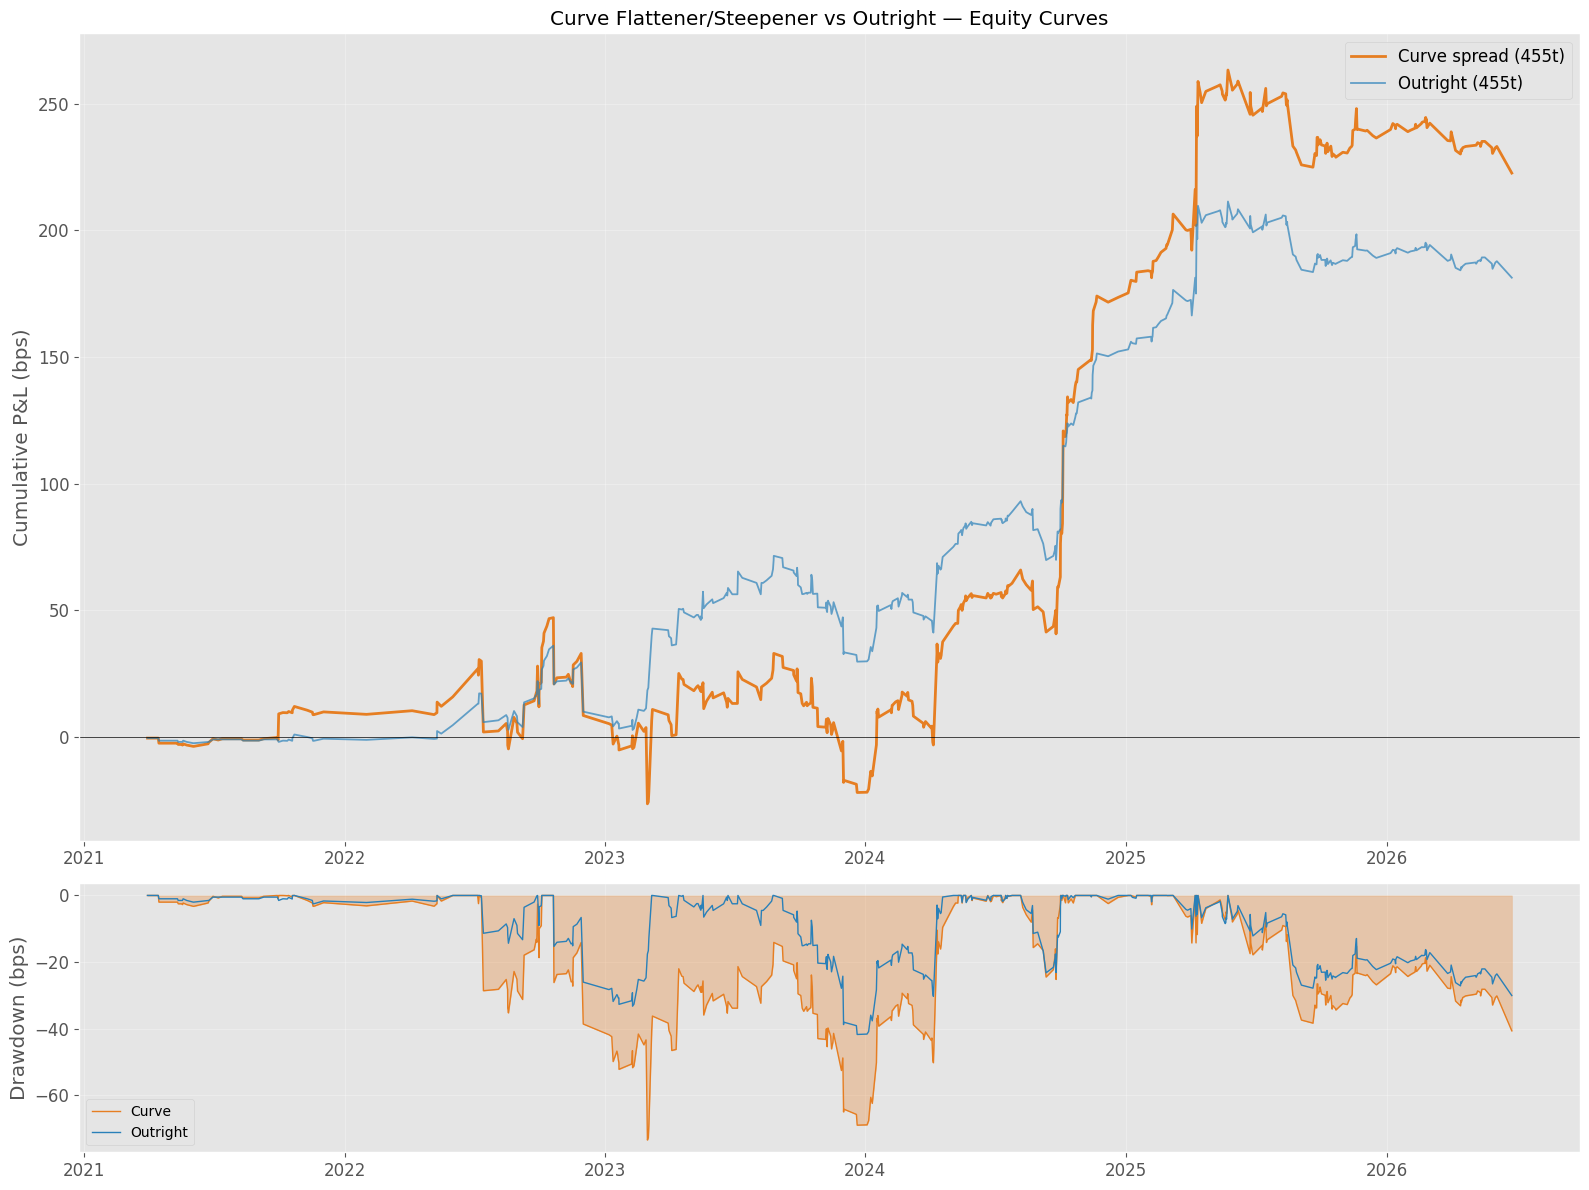

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={"height_ratios": [3, 1]})
ax = axes[0]
ax.plot(merged["opened_at"].values, merged["cum_curve"].values,
        lw=2, color="#e67e22", label=f"Curve spread ({len(merged)}t)")
ax.plot(outright_s["opened_at"].values, outright_s["cum_outright"].values,
        lw=1.3, color="#2980b9", alpha=0.7, label=f"Outright ({len(outright_s)}t)")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative P&L (bps)")
ax.set_title("Curve Flattener/Steepener vs Outright — Equity Curves")
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)

ax2 = axes[1]
dd_c = merged["cum_curve"] - merged["cum_curve"].cummax()
dd_o = outright_s["cum_outright"] - outright_s["cum_outright"].cummax()
ax2.fill_between(merged["opened_at"].values, dd_c.values, 0, alpha=0.3, color="#e67e22")
ax2.plot(merged["opened_at"].values, dd_c.values, lw=1, color="#e67e22", label="Curve")
ax2.plot(outright_s["opened_at"].values, dd_o.values, lw=1, color="#2980b9", label="Outright")
ax2.set_ylabel("Drawdown (bps)"); ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Calendar-Year Breakdown

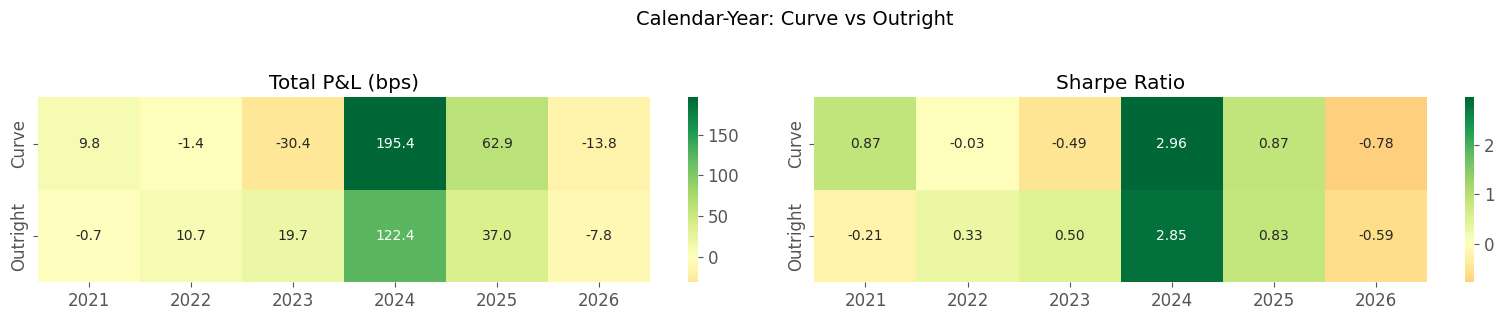

Curve year stats:


,trades,total,avg,hit,std,sharpe
year,,,,,,
2021,39,+9.8,+0.252,53.8%,1.81,0.87
2022,49,-1.4,-0.029,59.2%,7.97,-0.03
2023,97,-30.4,-0.313,44.3%,6.32,-0.49
2024,121,+195.4,+1.615,61.2%,6.00,2.96
2025,104,+62.9,+0.605,51.0%,7.05,0.87
2026,45,-13.8,-0.307,57.8%,2.64,-0.78



Outright year stats:


,trades,total,avg,hit,std,sharpe
year,,,,,,
2021,39,-0.7,-0.019,51.3%,0.55,-0.21
2022,49,+10.7,+0.218,63.3%,4.69,0.33
2023,97,+19.7,+0.204,50.5%,4.02,0.50
2024,121,+122.4,+1.012,64.5%,3.91,2.85
2025,104,+37.0,+0.355,53.8%,4.38,0.83
2026,45,-7.8,-0.173,60.0%,1.96,-0.59


In [8]:
# Year breakdown for curve and outright
yr_curve = merged.groupby("year").agg(
    trades=("curve_bps", "count"), total=("curve_bps", "sum"),
    avg=("curve_bps", "mean"), hit=("profitable", "mean"),
    std=("curve_bps", "std"))
yr_curve["sharpe"] = (yr_curve["avg"] / yr_curve["std"]) * np.sqrt(yr_curve["trades"])

outright_full = outright.copy()
outright_full["profitable"] = outright_full["pnl_bps"] > 0
yr_out = outright_full.groupby("year").agg(
    trades=("pnl_bps", "count"), total=("pnl_bps", "sum"),
    avg=("pnl_bps", "mean"), hit=("profitable", "mean"),
    std=("pnl_bps", "std"))
yr_out["sharpe"] = (yr_out["avg"] / yr_out["std"]) * np.sqrt(yr_out["trades"])

# Side by side heatmap
all_years = sorted(set(yr_curve.index) | set(yr_out.index))
hm_data = pd.DataFrame(index=["Curve", "Outright"], columns=all_years, dtype=float)
hm_sr = hm_data.copy()
for yr in all_years:
    if yr in yr_curve.index:
        hm_data.loc["Curve", yr] = yr_curve.loc[yr, "total"]
        hm_sr.loc["Curve", yr] = yr_curve.loc[yr, "sharpe"]
    if yr in yr_out.index:
        hm_data.loc["Outright", yr] = yr_out.loc[yr, "total"]
        hm_sr.loc["Outright", yr] = yr_out.loc[yr, "sharpe"]

fig, axes = plt.subplots(1, 2, figsize=(16, 3))
sns.heatmap(hm_data.astype(float), annot=True, fmt=".1f", cmap="RdYlGn", center=0, ax=axes[0])
axes[0].set_title("Total P&L (bps)")
sns.heatmap(hm_sr.astype(float), annot=True, fmt=".2f", cmap="RdYlGn", center=0, ax=axes[1])
axes[1].set_title("Sharpe Ratio")
plt.suptitle("Calendar-Year: Curve vs Outright", fontsize=14, y=1.05)
plt.tight_layout(); plt.show()

print("Curve year stats:")
display(yr_curve.style.format({"total": "{:+.1f}", "avg": "{:+.3f}", "hit": "{:.1%}",
                                "std": "{:.2f}", "sharpe": "{:.2f}"}))
print("\nOutright year stats:")
display(yr_out.style.format({"total": "{:+.1f}", "avg": "{:+.3f}", "hit": "{:.1%}",
                              "std": "{:.2f}", "sharpe": "{:.2f}"}))

## 8. Hawk vs Dove — Curve Trades

,trades,total,avg,hit,front_total,back_total
direction_label,,,,,,
hawk,380,+235.1,+0.619,54.2%,+37.8,+197.3
dove,75,-12.5,-0.167,53.3%,+3.5,-16.0


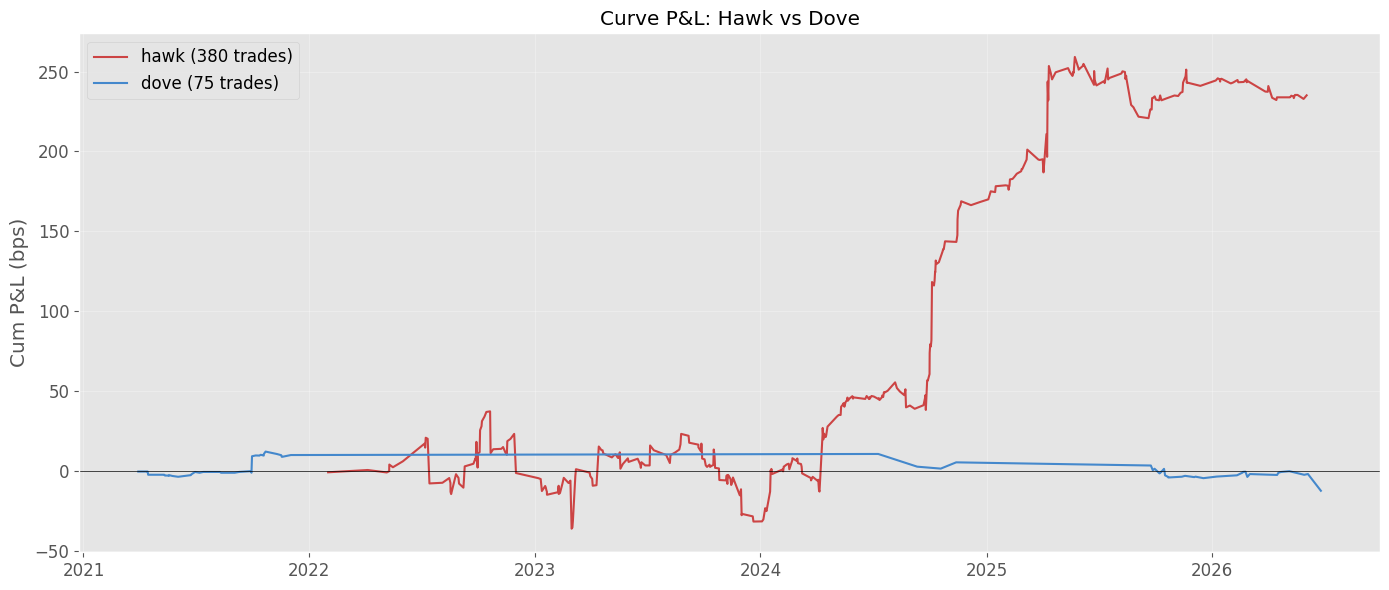

In [9]:
dir_stats = merged.groupby("direction_label").agg(
    trades=("curve_bps", "count"), total=("curve_bps", "sum"),
    avg=("curve_bps", "mean"), hit=("profitable", "mean"),
    front_total=("front_bps", "sum"), back_total=("back_bps", "sum"),
).sort_values("total", ascending=False)
display(dir_stats.style.format({
    "total": "{:+.1f}", "avg": "{:+.3f}", "hit": "{:.1%}",
    "front_total": "{:+.1f}", "back_total": "{:+.1f}"}))

fig, ax = plt.subplots(figsize=(14, 6))
for label, color in [("hawk", "#cc4444"), ("dove", "#4488cc")]:
    sub = merged[merged["direction_label"] == label].sort_values("opened_at")
    if len(sub) == 0: continue
    ax.plot(sub["opened_at"].values, sub["curve_bps"].cumsum().values,
            lw=1.5, color=color, label=f"{label} ({len(sub)} trades)")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cum P&L (bps)"); ax.set_title("Curve P&L: Hawk vs Dove")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Leg Correlation & Hedge Effectiveness

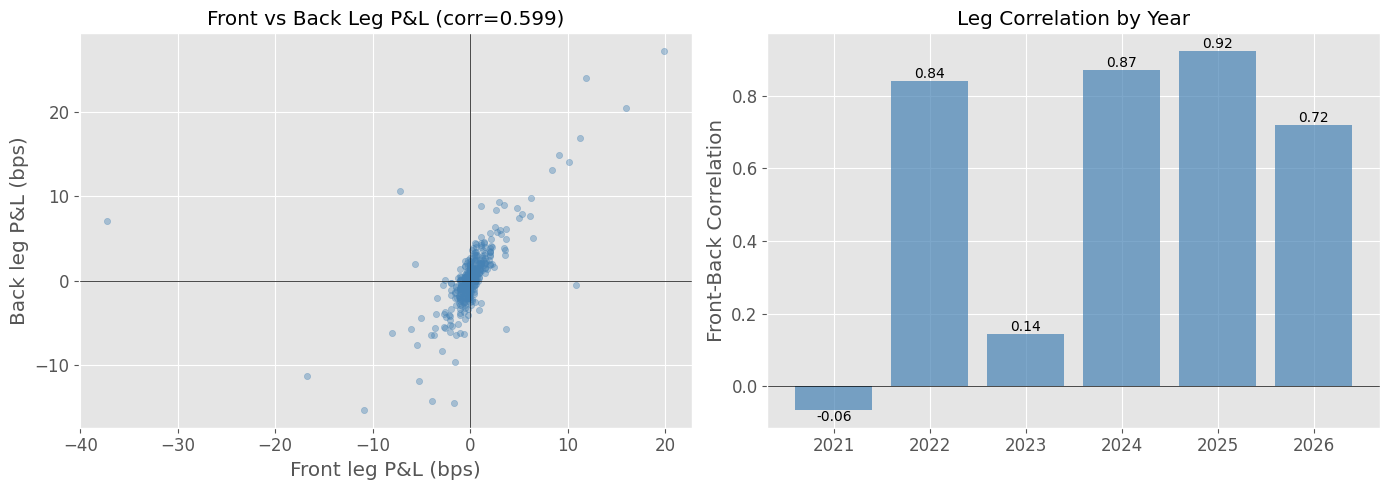

Leg correlation by year:
  2021: -0.065
  2022: 0.840
  2023: 0.143
  2024: 0.871
  2025: 0.923
  2026: 0.719

Full sample: 0.599

Interpretation: corr near +1 = legs move together (spread is tight, low vol)
corr near 0 = legs independent (spread captures relative value)
corr near -1 = legs move opposite (spread vol doubles — bad hedge)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(merged["front_bps"], merged["back_bps"], alpha=0.4, s=20, color="steelblue")
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
corr = merged["front_bps"].corr(merged["back_bps"])
ax.set_xlabel("Front leg P&L (bps)"); ax.set_ylabel("Back leg P&L (bps)")
ax.set_title(f"Front vs Back Leg P&L (corr={corr:.3f})")

# Year-by-year correlation
ax2 = axes[1]
yr_corrs = merged.groupby("year").apply(lambda g: g["front_bps"].corr(g["back_bps"]))
ax2.bar(yr_corrs.index.astype(str), yr_corrs.values, color="steelblue", alpha=0.7)
ax2.axhline(0, color="k", lw=0.5)
ax2.set_ylabel("Front-Back Correlation")
ax2.set_title("Leg Correlation by Year")
for i, (yr, c) in enumerate(yr_corrs.items()):
    ax2.text(i, c, f"{c:.2f}", ha="center", va="bottom" if c >= 0 else "top", fontsize=10)
plt.tight_layout(); plt.show()

# Hedge ratio analysis
print("Leg correlation by year:")
for yr, c in yr_corrs.items():
    print(f"  {yr}: {c:.3f}")
print(f"\nFull sample: {corr:.3f}")
print(f"\nInterpretation: corr near +1 = legs move together (spread is tight, low vol)")
print(f"corr near 0 = legs independent (spread captures relative value)")
print(f"corr near -1 = legs move opposite (spread vol doubles — bad hedge)")

## 10. Speaker Attribution — Curve

,trades,total,avg,hit
speaker,,,,
Williams,40,+46.0,+1.150,55.0%
Musalem,20,+42.1,+2.107,70.0%
Powell,31,+42.1,+1.357,51.6%
Barkin,51,+40.7,+0.798,52.9%
Bostic,58,+36.6,+0.631,62.1%
Bowman,60,+34.3,+0.571,50.0%
Collins,5,+28.7,+5.747,80.0%
Kugler,8,+20.6,+2.572,62.5%
Schmid,8,+20.5,+2.557,62.5%


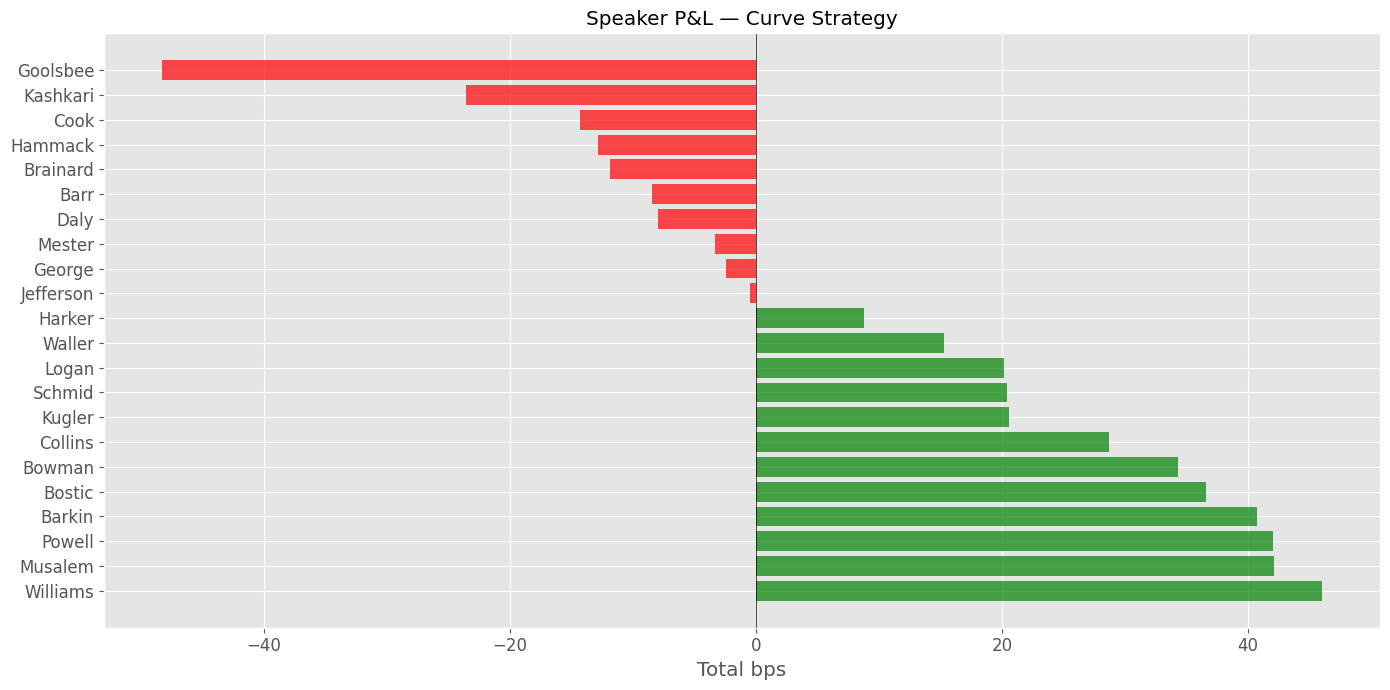

In [11]:
sp = merged.groupby("speaker").agg(
    trades=("curve_bps", "count"), total=("curve_bps", "sum"),
    avg=("curve_bps", "mean"), hit=("profitable", "mean"),
).sort_values("total", ascending=False)
display(sp.style.format({"total": "{:+.1f}", "avg": "{:+.3f}", "hit": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(14, 7))
colors = ["green" if x > 0 else "red" for x in sp["total"]]
ax.barh(sp.index, sp["total"], color=colors, alpha=0.7)
ax.axvline(0, color="k", lw=0.5); ax.set_xlabel("Total bps")
ax.set_title("Speaker P&L — Curve Strategy")
plt.tight_layout(); plt.show()

## 11. P&L Distribution — Curve vs Outright

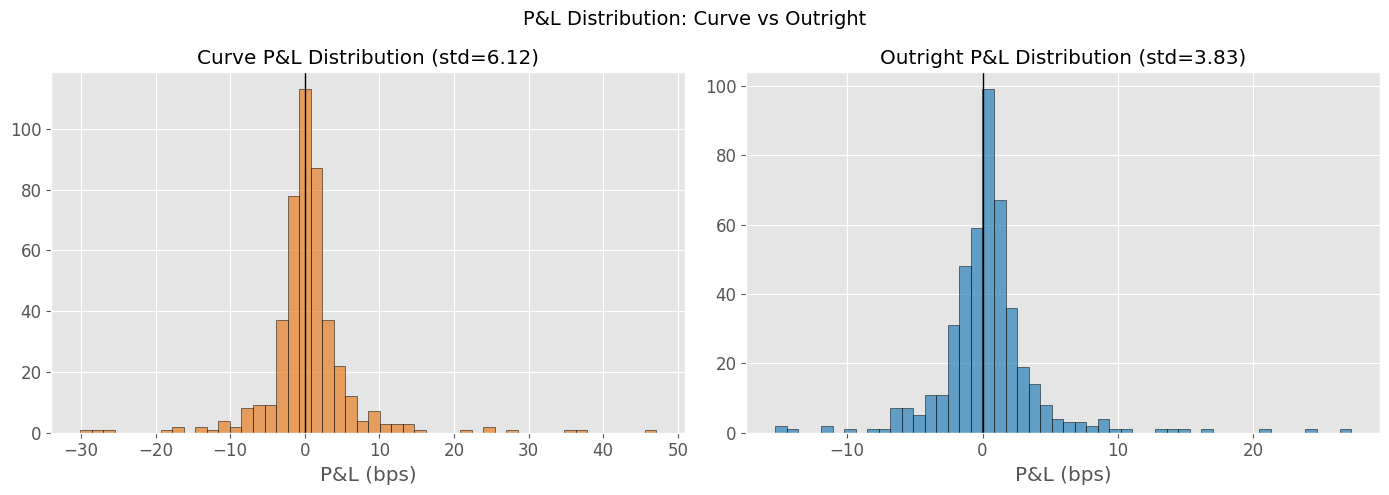

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(merged["curve_bps"], bins=50, alpha=0.7, color="#e67e22", edgecolor="black")
axes[0].axvline(0, color="k", lw=1)
axes[0].set_xlabel("P&L (bps)"); axes[0].set_title(f"Curve P&L Distribution (std={merged['curve_bps'].std():.2f})")

axes[1].hist(outright["pnl_bps"], bins=50, alpha=0.7, color="#2980b9", edgecolor="black")
axes[1].axvline(0, color="k", lw=1)
axes[1].set_xlabel("P&L (bps)"); axes[1].set_title(f"Outright P&L Distribution (std={outright['pnl_bps'].std():.2f})")

plt.suptitle("P&L Distribution: Curve vs Outright", fontsize=14)
plt.tight_layout(); plt.show()